In [1]:
from src.dataloading import EpiConfig, EpiDataOrchestrator
# get data
disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2011-06-01'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 4
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,

    min_date            = min_date,
    max_date            = max_date,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest, 

    num_quantiles       = 1,

    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,

    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,

    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  ,

    feature_popdens     = True,
    feature_gisd        = True,
    feature_popage      = True,
    feature_population_size=True
    )    


epidata_orchestrator  = (EpiDataOrchestrator(config)
                      .load_raw()
                      .harmonize_raw()
                      .process_data()
                      .build_features()
                      .normalize()
                      .finalize()
                      )

In [3]:
from src.dataloading import BaseLineDataLoaderManager, GraphDataLoaderManager
baselinedata             = BaseLineDataLoaderManager(epidata_orchestrator)

n_epochs        = 500
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

graphdataloader_ig       = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('identity_graph').build()
graphdataloader_gn       = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('geographical_neighbors1').build()
graphdataloader_cm21     = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('static_commuter24_1').build()


In [4]:
from src.models import SimpleGCNModel, GATv2LSTMModel, LSTMModel

In [5]:
from src.models import ClimaScaleModel, PersistenceModel, ClimateologyModel 
from src.evaluation import Evaluator

persistence = PersistenceModel(baselinedata)
persistence.forecast()

climateology = ClimateologyModel(baselinedata)
climateology.forecast()

climascale = ClimaScaleModel(baselinedata)
climascale.forecast()

baseline_models = [persistence, climateology, climascale]


==                    model1                    ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 23, 4), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 001 train loss: 0.8470, val loss: 1.4002 ✓ (new best)
Epoch 002 train loss: 0.6617, val loss: 1.0720 ✓ (new best)
Epoch 003 train loss: 0.5699, val loss: 0.8669 ✓ (new best)
Epoch 004 train loss: 0.5152, val loss: 0.7658 ✓ (new best)
Epoch 005 train loss: 0.4874, val loss: 0.6292 ✓ (new best)
Epoch 006 train loss: 0.4762, val loss: 0.6189 ✓ (new best)
Epoch 007 train loss: 0.4603, val loss: 0.5291 ✓ (new best)
Epoch 008 train loss: 0.4526, val loss: 0.5735 (patience: 1/15)
Epoch 009 train loss: 0.4373, val loss: 0.4823 ✓ (new best)
Epoch 010 train loss: 0.4309, val loss: 0.4914 (patience: 1/15)
Epoch 011 train loss: 0.4248, val loss: 0.4648 ✓ (new best)
Epoch 012 train loss: 0.4172, val loss: 0.4509 ✓ (new best)
Epoch 013 train loss: 0.4128, val loss: 0.4475 ✓ (new best)
Epoch 014 train los

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:241: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 15 epochs
Restored model from best validation loss: 0.3590
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 264.07it/s]

Test loss: 0.5373
forecasted ✓


GATv2LSTMModel(name='model1')

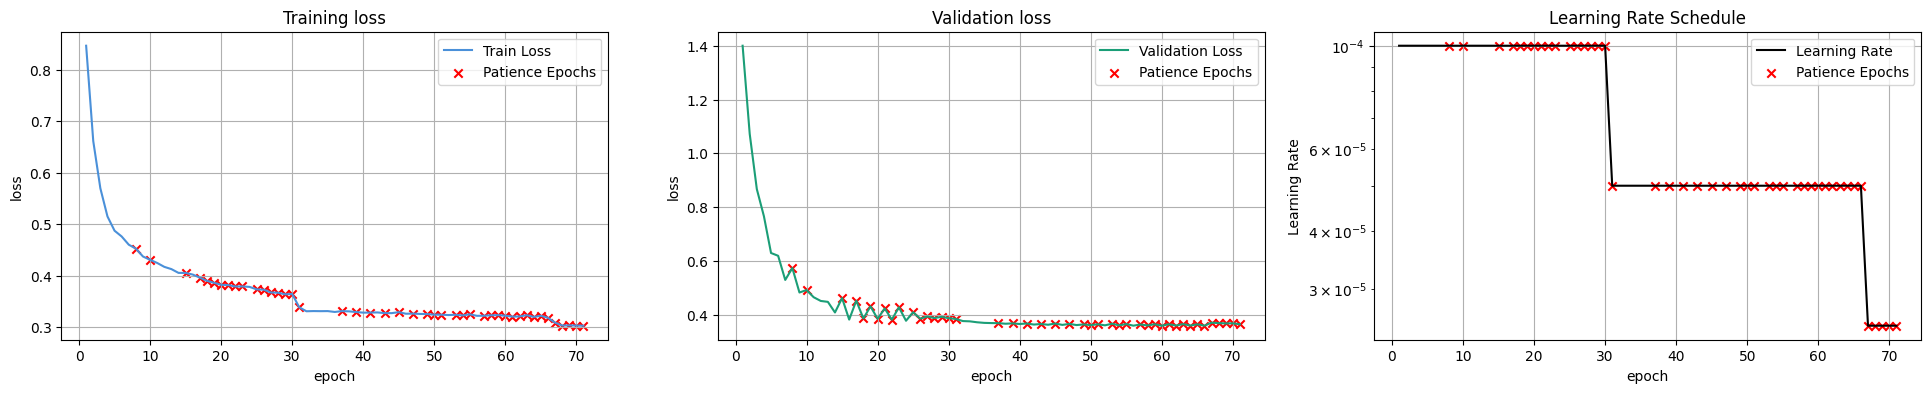

In [7]:
global_hparams = {
    'lr'    :   1e-4,
    'min_delta' : 0.0005,
    'n_epochs': 100,
    'patience':15,
    'scheduler':'plateau',
    'scheduler_kwargs': {'mode': 'min', 'factor': 0.5, 'patience': 5},
    }

ml1 = GATv2LSTMModel(graphdataloader_ig, name = 'model1',verbose = 2)
ml1.set_model_hparams()
ml1.set_global_hparams(**global_hparams)
ml1.train()
ml1.forecast()

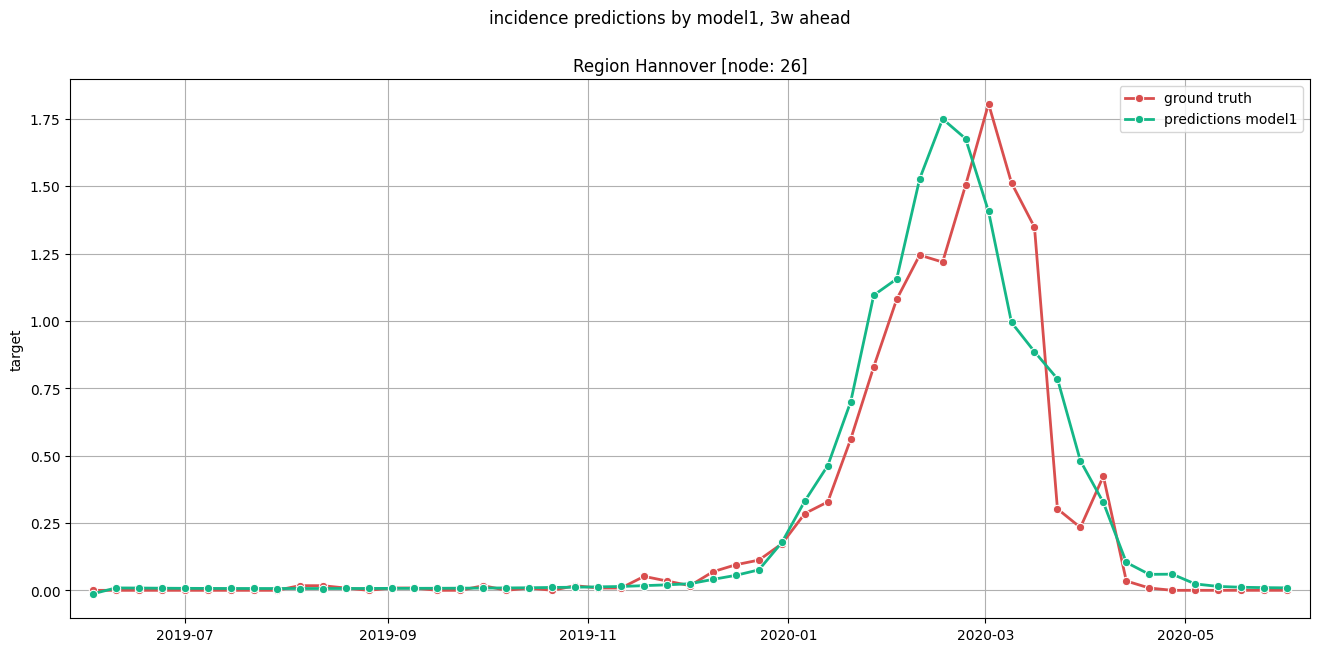

In [14]:
ml1.show_forecasts(26).show()


==                    model2                    ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 23, 4), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 001 train loss: 0.8904, val loss: 1.6698 ✓ (new best)
Epoch 002 train loss: 0.6962, val loss: 1.0125 ✓ (new best)
Epoch 003 train loss: 0.6070, val loss: 0.7862 ✓ (new best)
Epoch 004 train loss: 0.5507, val loss: 0.6513 ✓ (new best)
Epoch 005 train loss: 0.5172, val loss: 0.5676 ✓ (new best)
Epoch 006 train loss: 0.4897, val loss: 0.5207 ✓ (new best)
Epoch 007 train loss: 0.4661, val loss: 0.4830 ✓ (new best)
Epoch 008 train loss: 0.4473, val loss: 0.4646 ✓ (new best)
Epoch 009 train loss: 0.4341, val loss: 0.4348 ✓ (new best)
Epoch 010 train loss: 0.4290, val loss: 0.4457 (patience: 1/15)
Epoch 011 train loss: 0.4200, val loss: 0.4042 ✓ (new best)
Epoch 012 train loss: 0.4156, val loss: 0.4350 (patience: 1/15)
Epoch 013 train loss: 0.3999, val loss: 0.3727 ✓ (new best)
Epoch 014 train l

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:241: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 15 epochs
Restored model from best validation loss: 0.3309
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 264.53it/s]

Test loss: 0.5021
forecasted ✓


GATv2LSTMModel(name='model2')

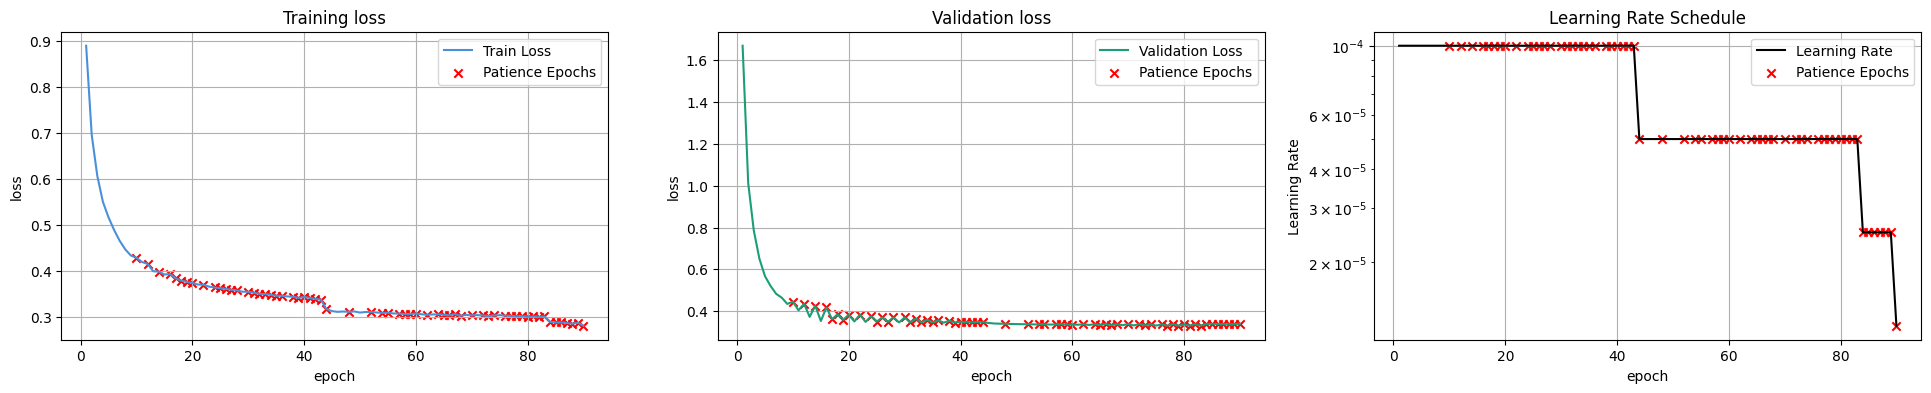

In [10]:
ml2 = GATv2LSTMModel(graphdataloader_gn,name = 'model2',verbose = 2)
ml2.set_model_hparams()
ml2.set_global_hparams(**global_hparams)
ml2.train()
ml2.forecast()

computing metrics:   0%|                                                                                                                                                                | 0/9 [00:00<?, ?it/s]

computing metrics:  89%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                 | 8/9 [00:06<00:00,  1.23it/s]/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58: RuntimeWarning: invalid value encountered in scalar divide
  r2=  float(1 - ss_res/ ss_tot)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58: RuntimeWarning: divide by zero encountered in scalar divide
  r2=  float(1 - ss_res/ ss_tot)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58: RuntimeWarning: invalid value encountered in scalar divide
  r2=  float(1 - ss_res/ ss_tot)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58: RuntimeWarning: divide by zero encountered in scalar divide
  r2=  float(1 - ss_res/ ss_tot)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58:

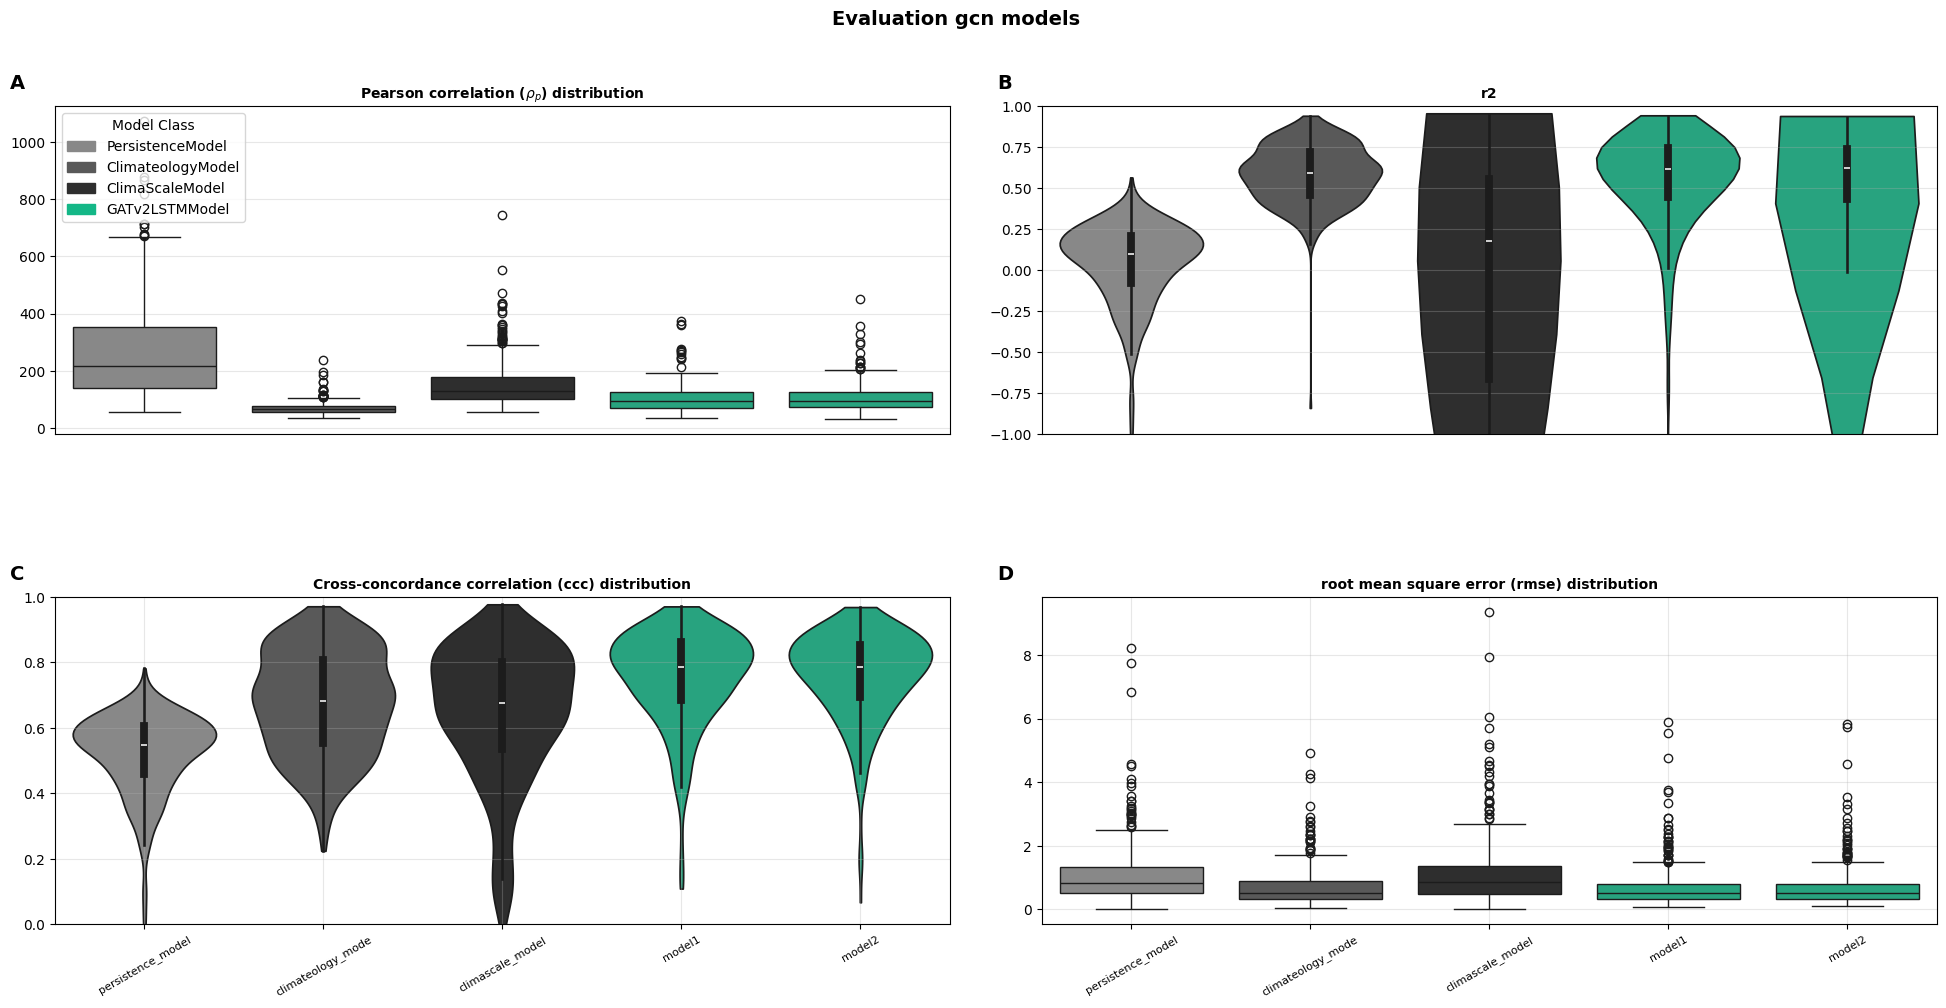

In [18]:
evaluation_experiment_sgnn = Evaluator(baseline_models + [ml1, ml2]).add_evaluation()
f_merged_raw    = evaluation_experiment_sgnn.plotter.plot_metric_compilation(metrics = ['mape','r2','ccc','rmse'], subfig_size = (8,4), plot_types = ['box','violin','violin','box']);

f_merged = (f_merged_raw
    .labels.change_suptitle(suptitle='Evaluation gcn models', fontsize = 14, fontweight = 'bold')
    .labels.set_suptitle_y(y=1.05)
    .labels.change_title('Pearson correlation ($\\rho_{p}$) distribution', fontweight = 'bold',     ax = 0)
    .labels.change_title('r2',  fontweight = 'bold',     ax = 1)
    .labels.change_title('Cross-concordance correlation (ccc) distribution', fontweight = 'bold',   ax = 2)    
    .labels.change_title('root mean square error (rmse) distribution', fontweight = 'bold',         ax = 3)    
    .labels.change_ylab('')
    .labels.change_xlab("")
    .ticks.change_xticks([], ax = 0)
    .ticks.change_xticks([], ax = 1)   
    # .layout.set_ylim([0,1],ax = 0)
    .layout.set_ylim([-1,1],ax = 1)
    .layout.set_ylim([0,1],ax = 2)        
    .labels.set_tag('A', y = 1.1, ax = 0)   
    .labels.set_tag('B', y = 1.1, ax = 1) 
    .labels.set_tag('C', y = 1.1, ax = 2) 
    .labels.set_tag('D', y = 1.1, ax = 3)      
    .legend.move('upper left', ax = 0)      
    .change_figsize(20,10)       
    )
f_merged.show()